<a href="https://colab.research.google.com/github/arunpradeep-g/Python-Programs/blob/main/02_KNN_employee_attrition_predict.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.neighbors import KNeighborsClassifier

In [2]:
# Recreate dataset
data = {
    'Age': [29, 35, 40, 28, 45, 25, 50, 30, 37, 26],
    'JobRole': [
        'Sales Executive', 'Research Scientist', 'Laboratory Technician',
        'Sales Executive', 'Manager', 'Research Scientist',
        'Manager', 'Sales Executive', 'Laboratory Technician', 'Research Scientist'
    ],
    'MonthlyIncome': [4800, 6000, 3400, 4300, 11000, 3500, 12000, 5000, 3100, 4500],
    'JobSatisfaction': [3,4,2,3,4,1,4,2,2,3],
    'YearsAtCompany': [4,8,6,3,15,2,20,5,9,2],
    'Attrition': [1,0,0,1,0,1,0,0,0,1]
}

In [3]:
df = pd.DataFrame(data)

# Encode JobRole
le = LabelEncoder()
df['JobRole'] = le.fit_transform(df['JobRole'])

# Use only 2 features for visualization
X = df[['Age', 'MonthlyIncome']].values
y = df['Attrition'].values

# Scale
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train KNN
knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(X_scaled, y)

KNeighborsClassifier(n_neighbors=3)

In [4]:
# Create mesh grid
x_min, x_max = X_scaled[:, 0].min() - 1, X_scaled[:, 0].max() + 1
y_min, y_max = X_scaled[:, 1].min() - 1, X_scaled[:, 1].max() + 1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 100),
                     np.linspace(y_min, y_max, 100))

# Predict decision boundary
Z = knn.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

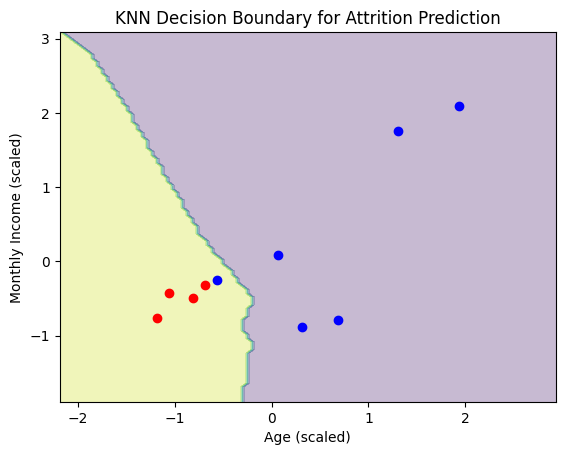

In [5]:
# Plot decision boundary
plt.figure()
plt.contourf(xx, yy, Z, alpha=0.3)

# Plot data points
for i in range(len(X_scaled)):
    if y[i] == 1:
        plt.scatter(X_scaled[i,0], X_scaled[i,1], color='red')
    else:
        plt.scatter(X_scaled[i,0], X_scaled[i,1], color='blue')

plt.xlabel('Age (scaled)')
plt.ylabel('Monthly Income (scaled)')
plt.title('KNN Decision Boundary for Attrition Prediction')

plt.show()